# 03: Funnel Analysis

**Dataset:** Google Analytics Sample Ecommerce Dataset (BigQuery public data)  
**Goal:** Measure drop-off at each step of the purchase funnel and identify where different segments lose users.  
**Reference:** [GA BigQuery Export Schema](https://support.google.com/analytics/answer/3437719?hl=en)   
**Funnel steps:** Product detail view → Add to cart → Checkout → Purchase  
**Method:** Session-level aggregation using `hits.eCommerceAction.action_type`

## 1. Setup

In [1]:
import os
from google.cloud import bigquery
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 1000)

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../credentials/bq-key.json"
client = bigquery.Client()
print("BigQuery client ready.")

BigQuery client ready.


## 2. Column Overview
*Key hit-level fields used in this notebook*

In [2]:
query_action_types = """
select 
    hits.type as hit_type,
    hits.eCommerceAction as action,
    hits.eCommerceAction.action_type as action_type,
    hits.eCommerceAction.option,
    hits.eCommerceAction.step,
    count(*) as hit_count
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_20170101`,
UNNEST(hits) as hits
GROUP BY hit_type, action, action_type, option, step
ORDER BY CAST(action_type AS INT64), hit_count DESC
"""
df_action_types = client.query(query_action_types).to_dataframe()
df_action_types

,hit_type,action,action_type,option,step,hit_count
0,PAGE,"{'action_type': '0', 'step': 1, 'option': None}",0,NaN,1,4713
1,EVENT,"{'action_type': '0', 'step': 1, 'option': None}",0,NaN,1,71
2,EVENT,"{'action_type': '1', 'step': 1, 'option': None}",1,NaN,1,646
3,PAGE,"{'action_type': '2', 'step': 1, 'option': None}",2,NaN,1,548
4,EVENT,"{'action_type': '2', 'step': 1, 'option': None}",2,NaN,1,3
5,EVENT,"{'action_type': '3', 'step': 1, 'option': None}",3,NaN,1,125
6,EVENT,"{'action_type': '4', 'step': 1, 'option': None}",4,NaN,1,22
7,PAGE,"{'action_type': '5', 'step': 1, 'option': 'Bil...",5,Billing and Shipping,1,34
8,PAGE,"{'action_type': '5', 'step': 2, 'option': 'Pay...",5,Payment,2,28
9,PAGE,"{'action_type': '5', 'step': 3, 'option': 'Rev...",5,Review,3,17


`hits.eCommerceAction.action_type` (from schema):  
Unknown = 0, Product list click = 1, Product detail view = 2, Add to cart = 3, Remove from cart = 4, Checkout = 5, Completed purchase = 6, Refund = 7, Checkout options = 8

For action_type = 5 (checkout), `step` indicates the checkout stage: 1 = Billing and Shipping, 2 = Payment, 3 = Review. For all other action types, `step` defaults to 1 and is not meaningful.

### Data Quality Check - Zero-Transaction Sources
*Sources with >1,000 sessions and 0 transactions across the full year*

In [3]:
query_zero_tx_sources = """
SELECT
    trafficSource.source,
    COUNT(*) AS sessions,
    SUM(totals.transactions) AS transactions
FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
GROUP BY trafficSource.source
HAVING transactions IS NULL AND sessions > 1000
ORDER BY sessions DESC
"""
df_zero_tx_sources = client.query(query_zero_tx_sources).to_dataframe()
df_zero_tx_sources

,source,sessions,transactions
0,analytics.google.com,16172,<NA>
1,baidu,3356,<NA>
2,qiita.com,1813,<NA>


`analytics.google.com` is excluded from all funnel queries - it is internal Google tool traffic (16,172 sessions, 0 purchases), not real customers. `baidu` and `qiita.com` are external users who could theoretically buy but did not convert; excluding them would be cherry-picking low-performing sources, so they remain in the analysis.

## 3. Overall Funnel
*Full year | How many sessions reach each step, and where does the biggest drop-off occur?*

In [4]:
query_funnel = """
WITH t1 AS (
    SELECT
        fullVisitorId,
        visitId,
        MAX(IF(hits.eCommerceAction.action_type = '2', 1, 0)) AS reached_product_view,
        MAX(IF(hits.eCommerceAction.action_type = '3', 1, 0)) AS reached_add_to_cart,
        MAX(IF(hits.eCommerceAction.action_type = '5', 1, 0)) AS reached_checkout,
        MAX(IF(hits.eCommerceAction.action_type = '6', 1, 0)) AS reached_purchase
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits
    WHERE trafficSource.source != 'analytics.google.com'
    GROUP BY fullVisitorId, visitId
)
SELECT
    COUNT(*)                  AS total_sessions,
    SUM(reached_product_view) AS product_view,
    SUM(reached_add_to_cart)  AS add_to_cart,
    SUM(reached_checkout)     AS checkout,
    SUM(reached_purchase)     AS purchase
FROM t1
"""
df_funnel = client.query(query_funnel).to_dataframe()
df_funnel

,total_sessions,product_view,add_to_cart,checkout,purchase
0,886624,123047,49626,22288,11551


In [5]:
steps = ['Total Sessions', 'Product View', 'Add to Cart', 'Checkout', 'Purchase']
counts = df_funnel.iloc[0].to_list()
tt_sessions = counts[0]
df_funnel_display = pd.DataFrame({
    'step': steps,
    'session': counts,
    'pct_of_total': [round(c/tt_sessions * 100,2) for c in counts],
    'drop_off_pct': [None] + [round((counts[i-1] - counts[i]) / counts[i-1] * 100, 2) for i in range(1, len(counts))]
})
df_funnel_display

,step,session,pct_of_total,drop_off_pct
0,Total Sessions,886624,100.00,NaN
1,Product View,123047,13.88,86.12
2,Add to Cart,49626,5.60,59.67
3,Checkout,22288,2.51,55.09
4,Purchase,11551,1.30,48.17


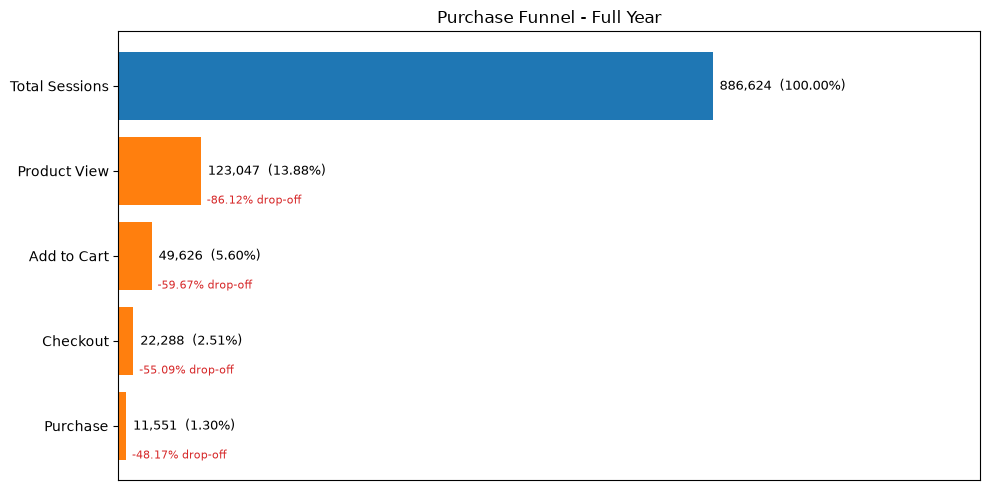

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

steps_rev = df_funnel_display['step'][::-1].tolist()
pcts_rev  = df_funnel_display['pct_of_total'][::-1].tolist()
sessions_rev = df_funnel_display['session'][::-1].tolist()
drops_rev = df_funnel_display['drop_off_pct'][::-1].tolist()

colors = ['tab:blue' if s == 'Total Sessions' else 'tab:orange' for s in steps_rev]
bars = ax.barh(steps_rev, pcts_rev, color=colors)
ax.bar_label(bars, labels=[f"{s:,}  ({p:.2f}%)" for s, p in zip(sessions_rev, pcts_rev)], padding=5, fontsize=9)

for i, d in enumerate(drops_rev):
    if pd.notna(d):
        ax.text(pcts_rev[i] + 1,  # to the right of the bar end
                i - 0.35,         # below the center of the bar
                f"-{d}% drop-off", color='tab:red', fontsize=8, va='center')

ax.set_title('Purchase Funnel - Full Year')
ax.set_xlim(0, 145)
ax.xaxis.set_visible(False)
plt.tight_layout()
plt.savefig('../images/funnel_overall.png', dpi=150)
plt.show()

**Insights:**

1. The biggest drop-off is at the very top: only 13.88% of sessions ever reach a product detail page. 86% of visitors bounce or browse without clicking into any product - this is where the most sessions are lost.
2. Once someone views a product, ~40% add to cart. That is a reasonable interest-to-intent rate.
3. Cart to checkout loses ~55% - over half of people who add something do not start checkout.
4. Checkout to purchase is the strongest step: ~51.9% complete once they start, meaning the payment flow itself is not the main problem.
5. The overall session-to-purchase rate is 1.30%, consistent with the 1.34% CR from EDA. `analytics.google.com` (16,131 sessions, 0 purchases) is excluded throughout to avoid diluting funnel rates with non-customer traffic.

### 3a. Checkout Sub-steps
*Within the 22,288 sessions that reached checkout, where exactly do users drop off? Checkout has 3 steps: Billing & Shipping → Payment → Review → Purchase.*

In [7]:
# note: WHERE reached_billing = 1 restricts to sessions that entered checkout (step 1);
# 20,829 of the 22,288 checkout sessions had a step-1 hit - the gap is incomplete event tracking
query_checkout_steps = """
WITH t1 AS (
    SELECT
        fullVisitorId,
        visitId,
        MAX(IF(hits.eCommerceAction.action_type = '5' AND hits.eCommerceAction.step = 1, 1, 0)) AS reached_billing,
        MAX(IF(hits.eCommerceAction.action_type = '5' AND hits.eCommerceAction.step = 2, 1, 0)) AS reached_payment,
        MAX(IF(hits.eCommerceAction.action_type = '5' AND hits.eCommerceAction.step = 3, 1, 0)) AS reached_review,
        MAX(IF(hits.eCommerceAction.action_type = '6', 1, 0)) AS reached_purchase
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits
    WHERE trafficSource.source != 'analytics.google.com'
      AND hits.eCommerceAction.action_type IN ('5', '6')
    GROUP BY fullVisitorId, visitId
)
SELECT
    SUM(reached_billing)  AS billing_shipping,
    SUM(reached_payment)  AS payment,
    SUM(reached_review)   AS review,
    SUM(reached_purchase) AS purchase
FROM t1
WHERE reached_billing = 1
"""
df_checkout_steps = client.query(query_checkout_steps).to_dataframe()
df_checkout_steps

,billing_shipping,payment,review,purchase
0,20829,15335,10861,10710


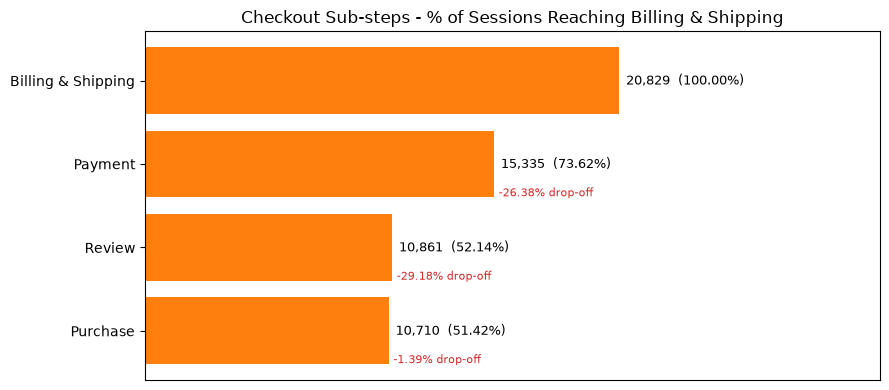

,step,sessions,pct_of_checkout,drop_off_pct
0,Billing & Shipping,20829,100.00,NaN
1,Payment,15335,73.62,26.38
2,Review,10861,52.14,29.18
3,Purchase,10710,51.42,1.39


In [8]:
steps_co = ['Billing & Shipping', 'Payment', 'Review', 'Purchase']
cols_co  = ['billing_shipping', 'payment', 'review', 'purchase']
counts_co = df_checkout_steps.iloc[0].to_list()
top_co = counts_co[0]

df_checkout_display = pd.DataFrame({
    'step': steps_co,
    'sessions': counts_co,
    'pct_of_checkout': [round(c / top_co * 100, 2) for c in counts_co],
    'drop_off_pct': [None] + [round((counts_co[i-1] - counts_co[i]) / counts_co[i-1] * 100, 2) for i in range(1, len(counts_co))]
})

fig, ax = plt.subplots(figsize=(9, 4))
steps_rev   = steps_co[::-1]
pcts_rev    = [round(c / top_co * 100, 2) for c in counts_co][::-1]
sessions_rev = counts_co[::-1]
drops_rev   = df_checkout_display['drop_off_pct'].tolist()[::-1]

bars = ax.barh(steps_rev, pcts_rev, color='tab:orange')
ax.bar_label(bars, labels=[f"{s:,}  ({p:.2f}%)"
             for s, p in zip(sessions_rev, pcts_rev)], padding=5, fontsize=9)

for i, d in enumerate(drops_rev):
    if pd.notna(d):
        ax.text(pcts_rev[i] + 1, i - 0.35, f"-{d}% drop-off",
                color='tab:red', fontsize=8, va='center')

ax.set_title('Checkout Sub-steps - % of Sessions Reaching Billing & Shipping')
ax.set_xlim(0, 155)
ax.xaxis.set_visible(False)
plt.tight_layout()
plt.savefig('../images/funnel_checkout_steps.png', dpi=150)
plt.show()
df_checkout_display

**Insights:**

1. The biggest drop-off within checkout is at Payment (26.38%) and Review (29.18%) - not at the final confirm step. Users who enter billing info often abandon when they see shipping costs or face friction entering payment details.
2. Once a user reaches the Review screen and sees the order summary, almost all of them complete the purchase - only 1.39% drop off at the final confirm step. The checkout button itself is not the problem.
3. Note: Section 3 shows 22,288 sessions reaching checkout overall, but only 20,829 recorded a Billing & Shipping hit (step 1). The 1,459 gap likely reflects sessions where a checkout event fired without a complete step sequence being tracked.

## 4. Funnel by Device
*Does mobile drop off earlier or steeper than desktop at a specific step?*

EDA showed desktop (Chrome) converts at 1.76% while Safari converts at only 0.43%, and mobile browsers (Safari in-app, Android Webview) sit below 0.2%. But overall CR alone does not tell us where mobile loses users. This section breaks the funnel down by device to pinpoint whether the mobile problem is at the top (not engaging with products), the middle (not committing to cart), or the bottom (checkout friction).

In [9]:
query_funnel_device = """
WITH t1 AS (
    SELECT
        fullVisitorId,
        visitId,
        device.deviceCategory AS device,
        MAX(IF(hits.eCommerceAction.action_type = '2', 1, 0)) AS reached_product_view,
        MAX(IF(hits.eCommerceAction.action_type = '3', 1, 0)) AS reached_add_to_cart,
        MAX(IF(hits.eCommerceAction.action_type = '5', 1, 0)) AS reached_checkout,
        MAX(IF(hits.eCommerceAction.action_type = '6', 1, 0)) AS reached_purchase
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits
    WHERE trafficSource.source != 'analytics.google.com'
    GROUP BY fullVisitorId, visitId, device
)
SELECT
    device,
    COUNT(*)                  AS total_sessions,
    SUM(reached_product_view) AS product_view,
    SUM(reached_add_to_cart)  AS add_to_cart,
    SUM(reached_checkout)     AS checkout,
    SUM(reached_purchase)     AS purchase
FROM t1
GROUP BY device
ORDER BY total_sessions DESC
"""
df_funnel_device = client.query(query_funnel_device).to_dataframe()
df_funnel_device

,device,total_sessions,product_view,add_to_cart,checkout,purchase
0,desktop,647832,93597,39990,19232,10527
1,mobile,208445,25812,8381,2672,856
2,tablet,30347,3638,1255,384,168


In [10]:
steps = ['Total Sessions', 'Product View', 'Add to Cart', 'Checkout', 'Purchase']
cols = ['total_sessions', 'product_view', 'add_to_cart', 'checkout', 'purchase']

# note: reused in sections 5, 6, and 7 - always call with the same steps/cols order
def build_funnel_df(row, steps, cols):
    counts = [row[c] for c in cols]
    top = counts[0]
    return pd.DataFrame({
        'step': steps,
        'session': counts,
        'pct_of_total': [round(c / top * 100, 2) for c in counts],
        'drop_off_pct': [None] + [round((counts[i-1] - counts[i]) / counts[i-1] * 100, 2) for i in range(1, len(counts))]
    })

dfs = []
for _, row in df_funnel_device.iterrows():
    df = build_funnel_df(row, steps, cols)
    df['device'] = row['device']
    dfs.append(df)

df_funnel_device_display = pd.concat(dfs, ignore_index=True)
df_funnel_device_display

,step,session,pct_of_total,drop_off_pct,device
0,Total Sessions,647832,100.00,NaN,desktop
1,Product View,93597,14.45,85.55,desktop
2,Add to Cart,39990,6.17,57.27,desktop
3,Checkout,19232,2.97,51.91,desktop
4,Purchase,10527,1.62,45.26,desktop
5,Total Sessions,208445,100.00,NaN,mobile
6,Product View,25812,12.38,87.62,mobile
7,Add to Cart,8381,4.02,67.53,mobile
8,Checkout,2672,1.28,68.12,mobile
9,Purchase,856,0.41,67.96,mobile


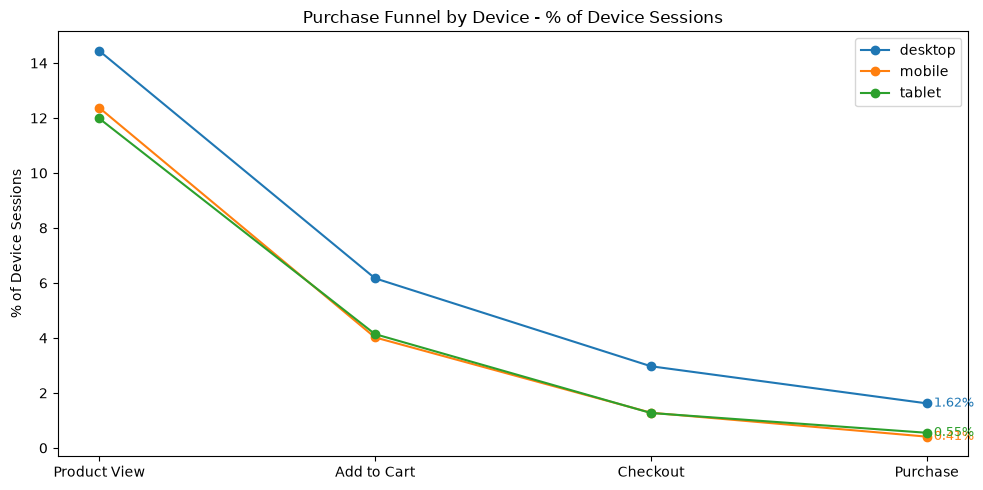

In [11]:
steps_plot = ['Product View', 'Add to Cart', 'Checkout', 'Purchase']
cols_plot = ['product_view', 'add_to_cart', 'checkout', 'purchase']
colors = {'desktop': 'tab:blue', 'mobile': 'tab:orange', 'tablet': 'tab:green'}

fig, ax = plt.subplots(figsize=(10, 5))
for _, row in df_funnel_device.iterrows():
    device = row['device']
    pcts = [round(row[c] / row['total_sessions'] * 100, 2) for c in cols_plot]
    ax.plot(steps_plot, pcts, marker='o', label=device, color=colors[device])
    ax.annotate(f"{pcts[-1]}%", xy=(steps_plot[-1], pcts[-1]),
                xytext=(5, 0), textcoords='offset points', fontsize=9, color=colors[device], va='center')

ax.set_title('Purchase Funnel by Device - % of Device Sessions')
ax.set_ylabel('% of Device Sessions')
ax.legend()
plt.tight_layout()
plt.savefig('../images/funnel_by_device.png', dpi=150)
plt.show()

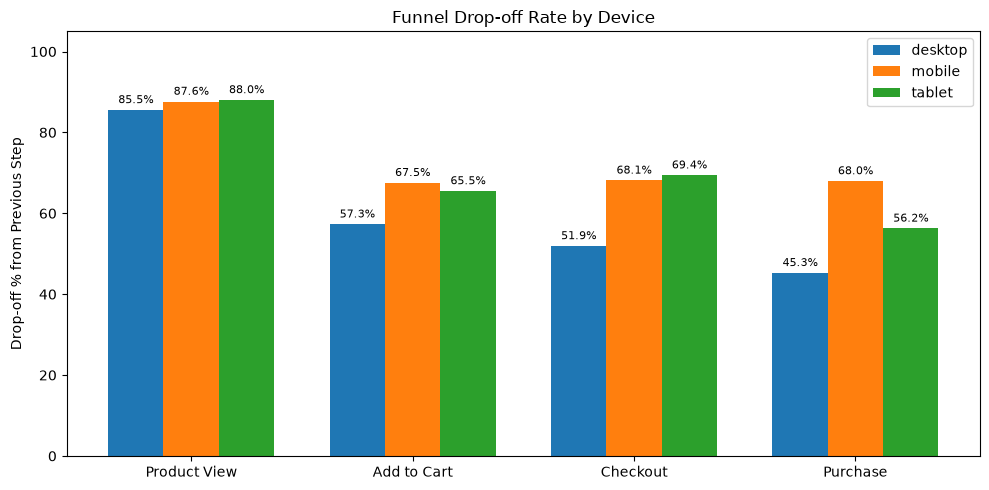

In [12]:
steps_plot = ['Product View', 'Add to Cart', 'Checkout', 'Purchase']
colors = {'desktop': 'tab:blue', 'mobile': 'tab:orange', 'tablet': 'tab:green'}

x = np.arange(len(steps_plot))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

for i, device in enumerate(['desktop', 'mobile', 'tablet']):
    df_dev = df_funnel_device_display[df_funnel_device_display['device'] == device]
    drop_offs = df_dev[df_dev['step'].isin(steps_plot)]['drop_off_pct'].tolist()
    bars = ax.bar(x + i * width, drop_offs, width, label=device, color=colors[device])
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)

ax.set_title('Funnel Drop-off Rate by Device')
ax.set_ylabel('Drop-off % from Previous Step')
ax.set_xticks(x + width)
ax.set_xticklabels(steps_plot)
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig('../images/funnel_device_dropoff.png', dpi=150)
plt.show()

**Insights:**

1. All devices lose a similar share of sessions at product view(85-88%). Desktop did not standout much in this step.
2. The gap opens at Add to Cart: desktop drops 57.3% vs mobile 67.5%. Mobile users view products but are less likely to commit.
3. At Checkout and Purchase, mobile's drop-off stays consistently around 68%. This points to checkout friction: small screen, payment input, and form filling are harder on mobile.
4. Mobile and tablet behave almost identically throughout the funnel despite tablet's larger screen. Both are touch devices and likely face similar UX friction.
5. Desktop's final purchase rate (1.62%) is 4x higher than mobile (0.41%). The gap is not from discovery but more likely from friction at every step after product view.

## 5. Funnel by Channel
*Do high-converting channels (Referral) enter the funnel deeper, or do they just drop off less?*

EDA showed Referral converts at ~6.25% - the highest of any channel - while Social drives 226K sessions but barely converts (0.06%). But a high overall CR could mean two different things: users who arrive already intending to buy (entering the funnel deeper), or users who engage with products but simply lose fewer at each step. This section breaks the funnel down by channel to distinguish between the two and identify where low-converting channels like Social actually lose their users.

In [13]:
query_funnel_channel = """
WITH t1 AS (
    SELECT
        fullVisitorId,
        visitId,
        channelGrouping,
        MAX(IF(hits.eCommerceAction.action_type = '2', 1, 0)) AS reached_product_view,
        MAX(IF(hits.eCommerceAction.action_type = '3', 1, 0)) AS reached_add_to_cart,
        MAX(IF(hits.eCommerceAction.action_type = '5', 1, 0)) AS reached_checkout,
        MAX(IF(hits.eCommerceAction.action_type = '6', 1, 0)) AS reached_purchase
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits
    WHERE trafficSource.source != 'analytics.google.com'
    GROUP BY fullVisitorId, visitId, channelGrouping
)
SELECT
    channelGrouping,
    COUNT(*)                  AS total_sessions,
    SUM(reached_product_view) AS product_view,
    SUM(reached_add_to_cart)  AS add_to_cart,
    SUM(reached_checkout)     AS checkout,
    SUM(reached_purchase)     AS purchase
FROM t1
GROUP BY channelGrouping
ORDER BY total_sessions DESC
"""
df_funnel_channel = client.query(query_funnel_channel).to_dataframe()
df_funnel_channel

,channelGrouping,total_sessions,product_view,add_to_cart,checkout,purchase
0,Organic Search,381137,62597,22357,8193,3443
1,Social,226020,4810,1766,408,104
2,Direct,142856,21073,9228,4335,2060
3,Referral,88570,26165,13035,8212,5322
4,Paid Search,25290,5064,1900,768,469
5,Affiliates,16372,1859,795,138,9
6,Display,6259,1461,541,231,143
7,(Other),120,18,4,3,1


In [14]:
cols = ['total_sessions', 'product_view', 'add_to_cart', 'checkout', 'purchase']
steps = ['Total Sessions', 'Product View', 'Add to Cart', 'Checkout', 'Purchase']

dfs = []
for _, row in df_funnel_channel.iterrows():
    df = build_funnel_df(row, steps, cols)
    df['channel'] = row['channelGrouping']
    dfs.append(df)

df_funnel_channel_display = pd.concat(dfs, ignore_index=True)
df_funnel_channel_display.head(10)

# (Other) excluded from charts - only 120 sessions and not a real marketing channel GA can classify

,step,session,pct_of_total,drop_off_pct,channel
0,Total Sessions,381137,100.00,NaN,Organic Search
1,Product View,62597,16.42,83.58,Organic Search
2,Add to Cart,22357,5.87,64.28,Organic Search
3,Checkout,8193,2.15,63.35,Organic Search
4,Purchase,3443,0.90,57.98,Organic Search
5,Total Sessions,226020,100.00,NaN,Social
6,Product View,4810,2.13,97.87,Social
7,Add to Cart,1766,0.78,63.28,Social
8,Checkout,408,0.18,76.90,Social
9,Purchase,104,0.05,74.51,Social


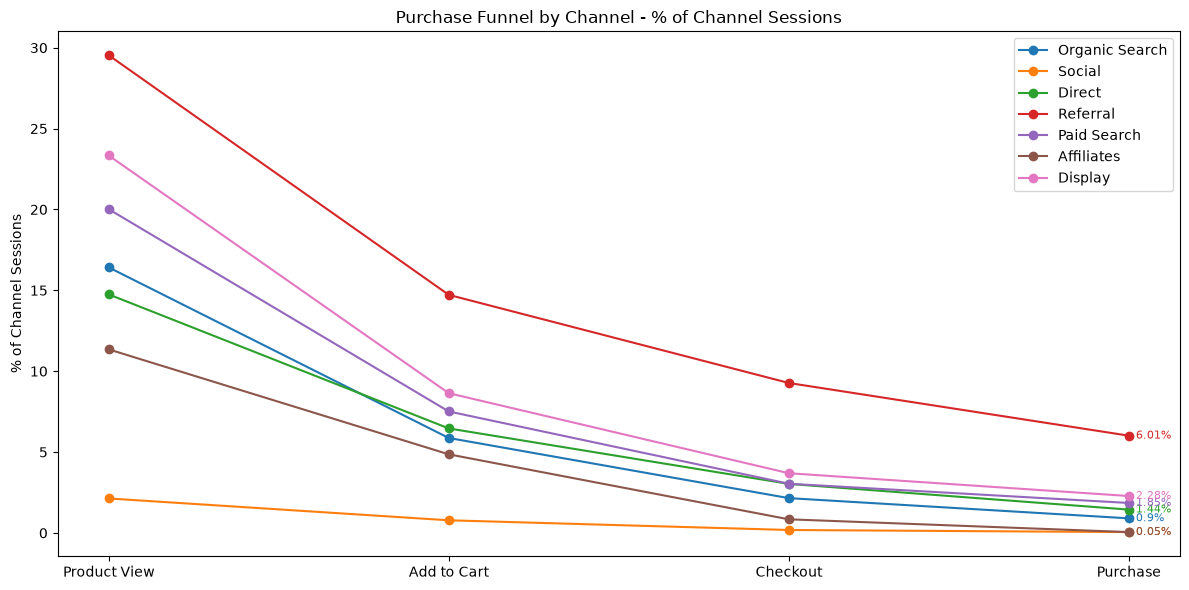

In [15]:
# note: channel_colors defined here and reused in the subplot cell below - run this cell first
steps_plot = ['Product View', 'Add to Cart', 'Checkout', 'Purchase']
cols_plot = ['product_view', 'add_to_cart', 'checkout', 'purchase']
channel_colors = {
    'Organic Search': 'tab:blue',
    'Social':         'tab:orange',
    'Direct':         'tab:green',
    'Referral':       'tab:red',
    'Paid Search':    'tab:purple',
    'Affiliates':     'tab:brown',
    'Display':        'tab:pink'
}

fig, ax = plt.subplots(figsize=(12, 6))
for _, row in df_funnel_channel[df_funnel_channel['channelGrouping'] != '(Other)'].iterrows():
    channel = row['channelGrouping']
    pcts = [round(row[c] / row['total_sessions'] * 100, 2) for c in cols_plot]
    ax.plot(steps_plot, pcts, marker='o', label=channel, color=channel_colors[channel])
    ax.annotate(f"{pcts[-1]}%", xy=(steps_plot[-1], pcts[-1]),
                xytext=(5, 0), textcoords='offset points', fontsize=8,
                color=channel_colors[channel], va='center')

ax.set_title('Purchase Funnel by Channel - % of Channel Sessions')
ax.set_ylabel('% of Channel Sessions')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../images/funnel_by_channel_line.png', dpi=150)
plt.show()

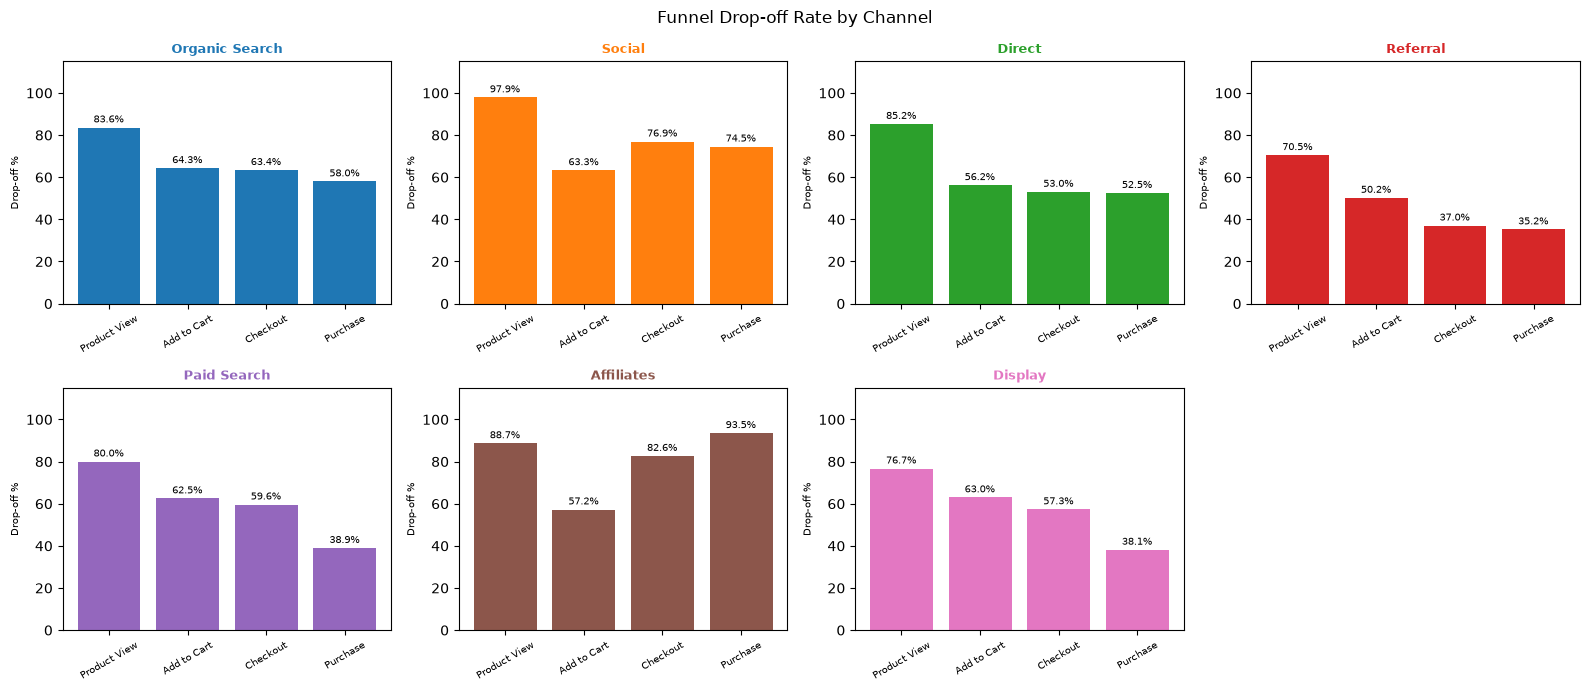

In [16]:
channels = df_funnel_channel[df_funnel_channel['channelGrouping'] != '(Other)']['channelGrouping'].tolist()
steps_plot = ['Product View', 'Add to Cart', 'Checkout', 'Purchase']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, channel in enumerate(channels):
    ax = axes[i]
    df_ch = df_funnel_channel_display[df_funnel_channel_display['channel'] == channel]
    drop_offs = df_ch[df_ch['step'].isin(steps_plot)]['drop_off_pct'].tolist()
    bars = ax.bar(steps_plot, drop_offs, color=channel_colors[channel])
    ax.bar_label(bars, fmt='%.1f%%', padding=2, fontsize=7)
    ax.set_title(channel, fontsize=9, fontweight='bold', color=channel_colors[channel])
    ax.set_ylim(0, 115)
    ax.tick_params(axis='x', labelrotation=30, labelsize=7)
    ax.set_ylabel('Drop-off %', fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Funnel Drop-off Rate by Channel', fontsize=12)
plt.tight_layout()
plt.savefig('../images/funnel_channel_dropoff.png', dpi=150)
plt.show()

**Insights:**

1. Referral's high CR comes from both sides - it enters the funnel deeper (29.5% product view vs 16.4% for Organic) AND drops off less at every subsequent step. Users arriving via a curated link already know what they want.
2. Social loses users at every step - 98% never reach a product page, and those who do still drop off heavily at checkout (76.9%) and purchase (74.5%). Social drives volume but attracts the lowest-intent visitors across the entire funnel.
3. Display and Paid Search start strong at product view (23.3% and 20%), suggesting paid traffic is well-targeted at the top. Both also show low final drop-offs (~38-39%), meaning users who reach checkout tend to complete the purchase.
4. Affiliates shows the opposite pattern to all other channels - drop-off actually increases toward the bottom (82.6% at checkout, 93.5% at purchase). Possible causes: affiliate fraud (click farms inflating cart adds for commission), coupon hunters who add to cart hoping for a discount then abandon when none appears, or simply small sample size making the % volatile.
5. Direct and Organic have similar product view drop-offs (~84-85%), but Direct outperforms Organic at every subsequent step (56.2% vs 64.3% at add to cart, 52.5% vs 58% at purchase). Direct visitors show stronger intent once they engage with a product.

## 6. Funnel by Country
*US vs rest of world - does international traffic reach the product page at the same rate?*

EDA showed the US generates 94% of transactions from 40% of sessions (3.14% CR), while all other countries combined convert below 0.5%. This section breaks the funnel down to identify whether international traffic fails at the discovery stage (never reaching a product page) or drops off later due to shipping, currency, or checkout friction.

In [17]:
query_funnel_country = """
WITH t1 AS (
    SELECT
        fullVisitorId,
        visitId,
        CASE WHEN geoNetwork.country = 'United States' THEN 'United States'
             ELSE 'Rest of World' END AS region,
        MAX(IF(hits.eCommerceAction.action_type = '2', 1, 0)) AS reached_product_view,
        MAX(IF(hits.eCommerceAction.action_type = '3', 1, 0)) AS reached_add_to_cart,
        MAX(IF(hits.eCommerceAction.action_type = '5', 1, 0)) AS reached_checkout,
        MAX(IF(hits.eCommerceAction.action_type = '6', 1, 0)) AS reached_purchase
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits
    WHERE trafficSource.source != 'analytics.google.com'
    GROUP BY fullVisitorId, visitId, region
)
SELECT
    region,
    COUNT(*)                  AS total_sessions,
    SUM(reached_product_view) AS product_view,
    SUM(reached_add_to_cart)  AS add_to_cart,
    SUM(reached_checkout)     AS checkout,
    SUM(reached_purchase)     AS purchase
FROM t1
GROUP BY region
ORDER BY total_sessions DESC
"""

df_funnel_country = client.query(query_funnel_country).to_dataframe()
df_funnel_country


,region,total_sessions,product_view,add_to_cart,checkout,purchase
0,Rest of World,525291,43544,15996,5165,563
1,United States,361334,79504,33631,17124,10989


In [18]:
cols = ['total_sessions', 'product_view', 'add_to_cart', 'checkout', 'purchase']
steps = ['Total Sessions', 'Product View', 'Add to Cart', 'Checkout', 'Purchase']

dfs = []
for _, row in df_funnel_country.iterrows():
    df = build_funnel_df(row, steps, cols)
    df['region'] = row['region']
    dfs.append(df)

df_funnel_country_display = pd.concat(dfs, ignore_index=True)
df_funnel_country_display


,step,session,pct_of_total,drop_off_pct,region
0,Total Sessions,525291,100.00,NaN,Rest of World
1,Product View,43544,8.29,91.71,Rest of World
2,Add to Cart,15996,3.05,63.26,Rest of World
3,Checkout,5165,0.98,67.71,Rest of World
4,Purchase,563,0.11,89.10,Rest of World
5,Total Sessions,361334,100.00,NaN,United States
6,Product View,79504,22.00,78.00,United States
7,Add to Cart,33631,9.31,57.70,United States
8,Checkout,17124,4.74,49.08,United States
9,Purchase,10989,3.04,35.83,United States


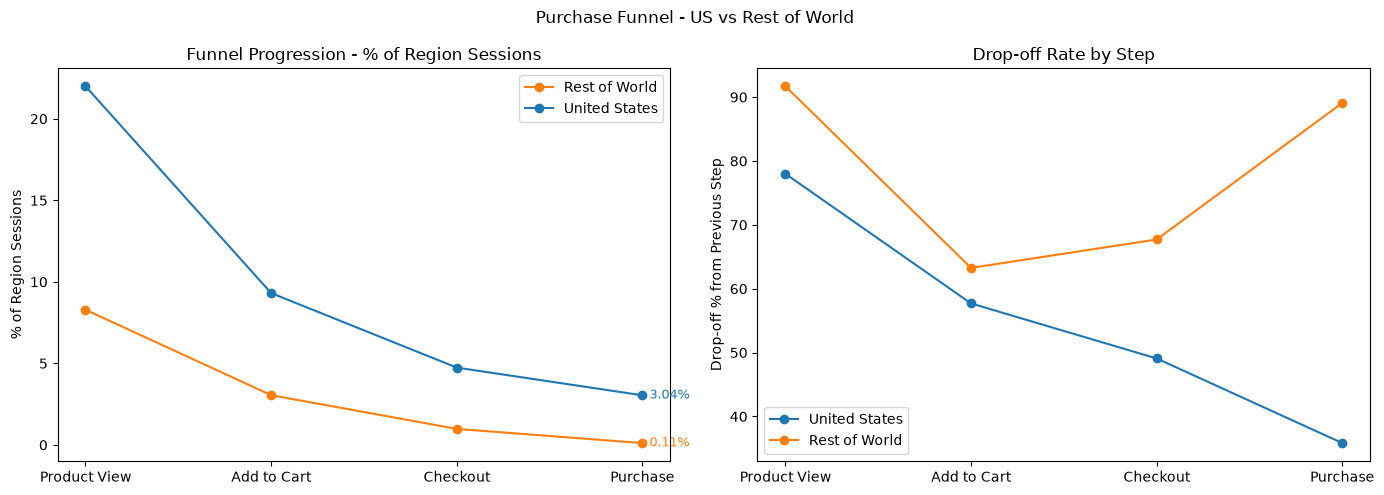

In [19]:
steps_plot = ['Product View', 'Add to Cart', 'Checkout', 'Purchase']
cols_plot = ['product_view', 'add_to_cart', 'checkout', 'purchase']
region_colors = {'United States': 'tab:blue', 'Rest of World': 'tab:orange'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left - funnel progression
ax = axes[0]
for _, row in df_funnel_country.iterrows():
    region = row['region']
    pcts = [round(row[c] / row['total_sessions'] * 100, 2) for c in cols_plot]
    ax.plot(steps_plot, pcts, marker='o', label=region, color=region_colors[region])
    ax.annotate(f"{pcts[-1]}%", xy=(steps_plot[-1], pcts[-1]),
                xytext=(5, 0), textcoords='offset points', fontsize=9,
                color=region_colors[region], va='center')
ax.set_title('Funnel Progression - % of Region Sessions')
ax.set_ylabel('% of Region Sessions')
ax.legend()

# right - drop-off rate
ax = axes[1]
for region in ['United States', 'Rest of World']:
    df_r = df_funnel_country_display[df_funnel_country_display['region'] == region]
    drop_offs = df_r[df_r['step'].isin(steps_plot)]['drop_off_pct'].tolist()
    ax.plot(steps_plot, drop_offs, marker='o', label=region, color=region_colors[region])
ax.set_title('Drop-off Rate by Step')
ax.set_ylabel('Drop-off % from Previous Step')
ax.legend()

plt.suptitle('Purchase Funnel - US vs Rest of World', fontsize=12)
plt.tight_layout()
plt.savefig('../images/funnel_by_country.png', dpi=150)
plt.show()

**Insights:**

1. International traffic starts weak - only 8.3% reach a product page vs 22% for the US, suggesting low purchase intent on arrival.
2. Rest of World drop-off spikes at checkout (67.7%) and purchase (89.1%) - a strong signal of checkout friction: shipping restrictions, unsupported payment methods, or currency barriers.
3. US shows a healthy declining drop-off pattern at every step - the deeper a user goes, the more committed they are.
4. US purchase rate (3.04%) is 28x higher than Rest of World (0.11%).

## 7. Funnel by Visitor Type
*Do returning visitors convert at a higher rate, and where in the funnel does the difference appear?*

A returning visitor has already seen the store - they know the brand, may have browsed products before, and are more likely to have purchase intent on return. `visitNumber` is a session-level field: `1` = first visit ever, `> 1` = any return visit.

In [20]:
query_funnel_visitor_type = """
WITH t1 AS (
    SELECT
        fullVisitorId,
        visitId,
        CASE WHEN visitNumber = 1 THEN 'New' ELSE 'Returning' END AS visitor_type,
        MAX(IF(hits.eCommerceAction.action_type = '2', 1, 0)) AS reached_product_view,
        MAX(IF(hits.eCommerceAction.action_type = '3', 1, 0)) AS reached_add_to_cart,
        MAX(IF(hits.eCommerceAction.action_type = '5', 1, 0)) AS reached_checkout,
        MAX(IF(hits.eCommerceAction.action_type = '6', 1, 0)) AS reached_purchase
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits
    WHERE trafficSource.source != 'analytics.google.com'
    GROUP BY fullVisitorId, visitId, visitor_type
)
SELECT
    visitor_type,
    COUNT(*)                  AS total_sessions,
    SUM(reached_product_view) AS product_view,
    SUM(reached_add_to_cart)  AS add_to_cart,
    SUM(reached_checkout)     AS checkout,
    SUM(reached_purchase)     AS purchase
FROM t1
GROUP BY visitor_type
ORDER BY visitor_type
"""
df_funnel_visitor = client.query(query_funnel_visitor_type).to_dataframe()
df_funnel_visitor

,visitor_type,total_sessions,product_view,add_to_cart,checkout,purchase
0,New,693201,81784,28775,10494,4474
1,Returning,193423,41263,20851,11794,7077


In [21]:
cols = ['total_sessions', 'product_view', 'add_to_cart', 'checkout', 'purchase']
steps = ['Total Sessions', 'Product View', 'Add to Cart', 'Checkout', 'Purchase']

dfs = []
for _, row in df_funnel_visitor.iterrows():
    df = build_funnel_df(row, steps, cols)
    df['visitor_type'] = row['visitor_type']
    dfs.append(df)
df_funnel_visitor_display = pd.concat(dfs, ignore_index=True)
df_funnel_visitor_display

,step,session,pct_of_total,drop_off_pct,visitor_type
0,Total Sessions,693201,100.00,NaN,New
1,Product View,81784,11.80,88.20,New
2,Add to Cart,28775,4.15,64.82,New
3,Checkout,10494,1.51,63.53,New
4,Purchase,4474,0.65,57.37,New
5,Total Sessions,193423,100.00,NaN,Returning
6,Product View,41263,21.33,78.67,Returning
7,Add to Cart,20851,10.78,49.47,Returning
8,Checkout,11794,6.10,43.44,Returning
9,Purchase,7077,3.66,39.99,Returning


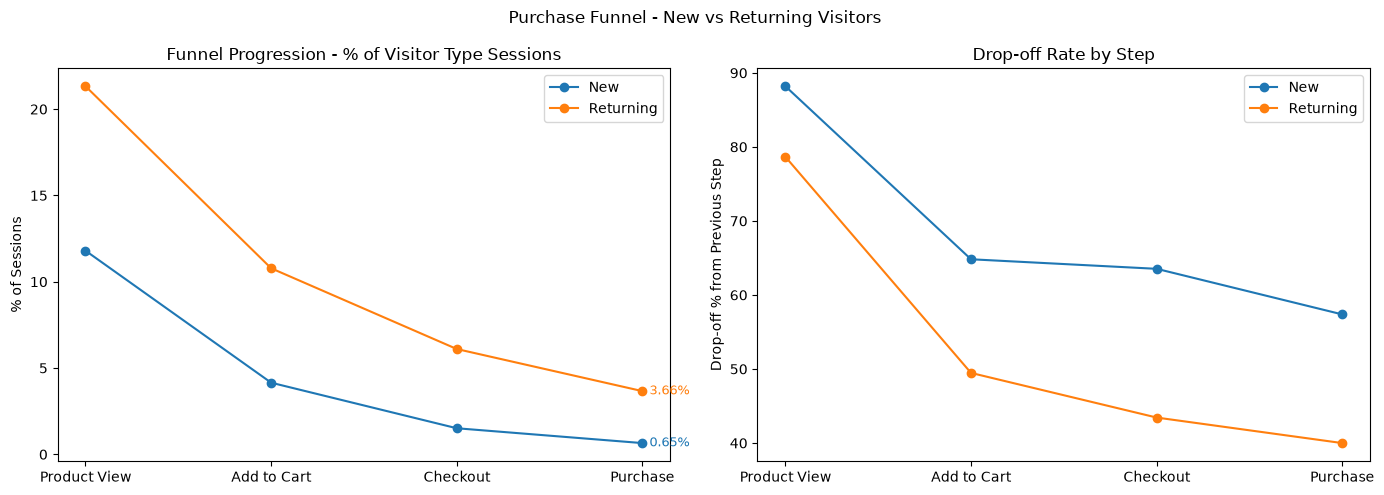

In [22]:
visitor_colors = {'New': 'tab:blue', 'Returning': 'tab:orange'}
steps_plot = ['Product View', 'Add to Cart', 'Checkout', 'Purchase']
cols_plot  = ['product_view', 'add_to_cart', 'checkout', 'purchase']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left - funnel progression
ax = axes[0]
for _, row in df_funnel_visitor.iterrows():
    vtype = row['visitor_type']
    pcts = [round(row[c] / row['total_sessions'] * 100, 2) for c in cols_plot]
    ax.plot(steps_plot, pcts, marker='o', label=vtype, color=visitor_colors[vtype])
    ax.annotate(f"{pcts[-1]}%", xy=(steps_plot[-1], pcts[-1]),
                xytext=(5, 0), textcoords='offset points', fontsize=9,
                color=visitor_colors[vtype], va='center')
ax.set_title('Funnel Progression - % of Visitor Type Sessions')
ax.set_ylabel('% of Sessions')
ax.legend()

# right - drop-off rate
ax = axes[1]
for vtype in ['New', 'Returning']:
    df_v = df_funnel_visitor_display[df_funnel_visitor_display['visitor_type'] == vtype]
    drop_offs = df_v[df_v['step'].isin(steps_plot)]['drop_off_pct'].tolist()
    ax.plot(steps_plot, drop_offs, marker='o', label=vtype, color=visitor_colors[vtype])
ax.set_title('Drop-off Rate by Step')
ax.set_ylabel('Drop-off % from Previous Step')
ax.legend()

plt.suptitle('Purchase Funnel - New vs Returning Visitors', fontsize=12)
plt.tight_layout()
plt.savefig('../images/funnel_by_visitor_type.png', dpi=150)
plt.show()

**Insights:**

1. Returning visitors convert at 3.66% vs 0.65% for new visitors - nearly 6x higher. The gap is not from one step but compounds across the entire funnel.
2. The gap opens at product view (21.33% vs 11.80%) - returning visitors arrive more likely to browse products, not just land and leave.
3. Returning visitors' drop-off declines at each step (79% → 49% → 43% → 40%), meaning they get more committed the deeper they go. New visitors stay stubbornly flat at 63-65% through cart, checkout, and purchase.
4. Note: `visitNumber` is cookie-based. A returning visitor on a different device or browser is counted as new - so the true gap may be even larger than the data shows.

## 8. Time-based Patterns
*Does time of day or day of week affect how far users progress through the funnel?*

Uses `visitStartTime` (Unix timestamp, session-level) converted to US Pacific time. All times reflect the store's primary market timezone.

### 8a. Hour of Day

In [23]:
# note: visitStartTime is a session-level Unix timestamp - preferred over hits.hour which is hit-level and requires UNNEST
query_funnel_hour = """
WITH t1 AS (
    SELECT
        fullVisitorId,
        visitId,
        EXTRACT(HOUR FROM DATETIME(TIMESTAMP_SECONDS(visitStartTime), 'America/Los_Angeles')) AS hour,
        MAX(IF(hits.eCommerceAction.action_type = '2', 1, 0)) AS reached_product_view,
        MAX(IF(hits.eCommerceAction.action_type = '3', 1, 0)) AS reached_add_to_cart,
        MAX(IF(hits.eCommerceAction.action_type = '5', 1, 0)) AS reached_checkout,
        MAX(IF(hits.eCommerceAction.action_type = '6', 1, 0)) AS reached_purchase
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits
    WHERE trafficSource.source != 'analytics.google.com'
    GROUP BY fullVisitorId, visitId, hour
)
SELECT
    hour,
    COUNT(*)                  AS total_sessions,
    SUM(reached_product_view) AS product_view,
    SUM(reached_add_to_cart)  AS add_to_cart,
    SUM(reached_checkout)     AS checkout,
    SUM(reached_purchase)     AS purchase
FROM t1
GROUP BY hour
ORDER BY hour
"""
df_funnel_hour = client.query(query_funnel_hour).to_dataframe()
df_funnel_hour

,hour,total_sessions,product_view,add_to_cart,checkout,purchase
0,0,30986,3274,1168,429,122
1,1,29871,2708,919,319,51
2,2,29392,2488,892,285,52
3,3,28895,2414,903,297,42
4,4,31190,2749,1001,340,91
5,5,35407,3431,1309,498,191
6,6,40864,4450,1859,777,390
7,7,44884,5632,2403,1119,600
8,8,47805,6723,2932,1372,783
9,9,48779,7064,2953,1456,780


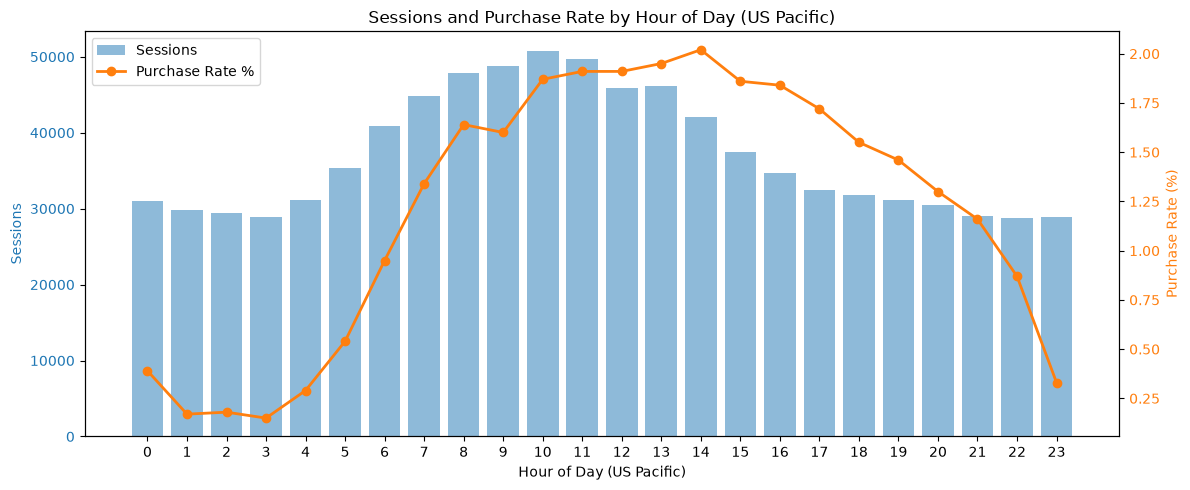

In [24]:
fig, ax1 = plt.subplots(figsize=(12, 5))

hours = df_funnel_hour['hour'].tolist()
sessions = df_funnel_hour['total_sessions'].tolist()
purchase_rate = [round(p / s * 100, 2) for p, s in zip(df_funnel_hour['purchase'], sessions)]

# bar: sessions volume
ax1.bar(hours, sessions, color='tab:blue', alpha=0.5, label='Sessions', width=0.8)
ax1.set_xlabel('Hour of Day (US Pacific)')
ax1.set_ylabel('Sessions', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(range(0, 24))

# line: purchase rate
ax2 = ax1.twinx()
ax2.plot(hours, purchase_rate, color='tab:orange', marker='o', linewidth=2, label='Purchase Rate %')
ax2.set_ylabel('Purchase Rate (%)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_title('Sessions and Purchase Rate by Hour of Day (US Pacific)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../images/funnel_by_hour.png', dpi=150)
plt.show()

**Insights:**

1. Sessions peak at 10 AM (50,804) but purchase rate peaks at 2 PM (2.02%). The 10 AM - 2 PM window is the highest-value slot - both high volume and high intent.
2. Overnight (1-3 AM Pacific) purchase rate bottoms out at 0.15-0.18% - likely non-US visitors browsing in their local daytime with no purchase intent.
3. Sessions stay flat overnight (~29-31K/hr) despite near-zero conversion, consistent with the Rest of World pattern from Section 6.

### 8b. Day of Week

In [25]:
query_funnel_dow = """
WITH t1 AS (
    SELECT
        fullVisitorId,
        visitId,
        FORMAT_DATE('%A', DATE(TIMESTAMP_SECONDS(visitStartTime), 'America/Los_Angeles')) AS day_of_week,
        EXTRACT(DAYOFWEEK FROM DATE(TIMESTAMP_SECONDS(visitStartTime), 'America/Los_Angeles')) AS day_num,
        MAX(IF(hits.eCommerceAction.action_type = '2', 1, 0)) AS reached_product_view,
        MAX(IF(hits.eCommerceAction.action_type = '3', 1, 0)) AS reached_add_to_cart,
        MAX(IF(hits.eCommerceAction.action_type = '5', 1, 0)) AS reached_checkout,
        MAX(IF(hits.eCommerceAction.action_type = '6', 1, 0)) AS reached_purchase
    FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
    UNNEST(hits) AS hits
    WHERE trafficSource.source != 'analytics.google.com'
    GROUP BY fullVisitorId, visitId, day_of_week, day_num
)
SELECT
    day_num,
    day_of_week,
    COUNT(*)                  AS total_sessions,
    SUM(reached_product_view) AS product_view,
    SUM(reached_add_to_cart)  AS add_to_cart,
    SUM(reached_checkout)     AS checkout,
    SUM(reached_purchase)     AS purchase
FROM t1
GROUP BY day_num, day_of_week
ORDER BY day_num
"""
df_funnel_dow = client.query(query_funnel_dow).to_dataframe()
df_funnel_dow['purchase_rate'] = (df_funnel_dow['purchase'] / df_funnel_dow['total_sessions'] * 100).round(2)
df_funnel_dow

,day_num,day_of_week,total_sessions,product_view,add_to_cart,checkout,purchase,purchase_rate
0,1,Sunday,98826,12793,4912,1978,947,0.96
1,2,Monday,138314,19629,8082,3774,2056,1.49
2,3,Tuesday,144445,20360,8383,3964,2028,1.4
3,4,Wednesday,143877,20766,8280,3744,1943,1.35
4,5,Thursday,139469,19924,8071,3635,1907,1.37
5,6,Friday,126337,18010,7459,3424,1887,1.49
6,7,Saturday,96213,11698,4479,1789,784,0.81


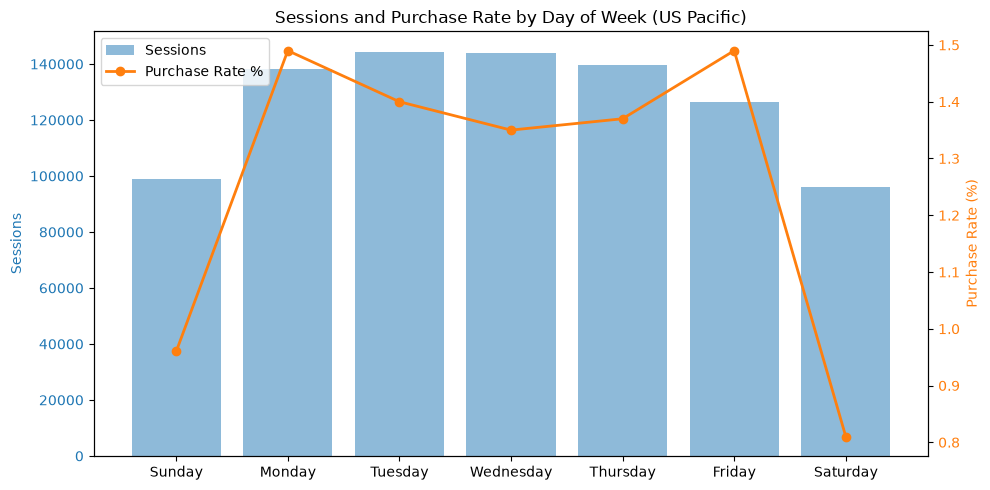

In [26]:
days_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
df_dow = df_funnel_dow.set_index('day_of_week').reindex(days_order)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(days_order, df_dow['total_sessions'], color='tab:blue', alpha=0.5, label='Sessions')
ax1.set_ylabel('Sessions', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(days_order, df_dow['purchase_rate'], color='tab:orange', marker='o', linewidth=2, label='Purchase Rate %')
ax2.set_ylabel('Purchase Rate (%)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_title('Sessions and Purchase Rate by Day of Week (US Pacific)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../images/funnel_by_dow.png', dpi=150)
plt.show()

**Insights:**

1. Weekends are the weakest days: Saturday (0.81%) and Sunday (0.96%) have both lower session volume (~33% fewer than peak weekdays) and the lowest purchase rates. Weekend visitors are browsing, not buying.
2. Monday and Friday tie for the highest purchase rate (1.49%). Monday buyers likely act on weekend browsing decisions; Friday buyers may be completing purchases before the weekend.
3. Mid-week (Tuesday-Wednesday) drives the most sessions but not the highest conversion - Wednesday dips to 1.35%, the lowest of any weekday.

## 9. Summary

### Key Findings

**Overall funnel**
- Only 1.30% of sessions result in a purchase
- 86% of sessions never reach a product page - the biggest loss is at the very top
- Once users engage with a product, the funnel narrows more gradually

**Checkout friction**
- 26% drop off at Payment and 29% at Review - likely from shipping cost surprise or payment entry friction
- Only 1.4% abandon at the final confirm step - the checkout button is not the problem

**Device**
- Mobile converts at 0.41% vs desktop at 1.62% (4x gap)
- The gap opens at Add to Cart and stays wide through checkout - UX friction, not a discovery problem

**Channel**
- Referral is the highest-quality channel: enters the funnel deeper (29.5% product view rate) AND drops off less at every step
- Social drives high volume but 98% of sessions never reach a product page
- Affiliates drop-off increases toward purchase - possible coupon-hunter behavior or attribution issues

**Geography**
- US converts at 3.04% vs Rest of World at 0.11% (28x gap)
- International traffic enters weak at product view (8.3% vs 22%) and 89% abandon before purchase - signals shipping/payment barriers

**Visitor type**
- Returning visitors convert at 3.66% vs 0.65% for new visitors (6x gap)
- Returning visitors are only 22% of sessions but account for 61% of purchases
- The gap compounds at every step - returning visitors get more committed the deeper they go; new visitors maintain high drop-offs throughout

**Time**
- 10 AM - 2 PM Pacific has both the highest session volume and highest purchase intent
- Weekdays convert at 1.35-1.49%; weekends drop to 0.81-0.96% - weekend visitors browse, not buy
- Monday and Friday are the best individual days for purchase intent (both 1.49%)

### Gaps and Limitations
- **No multi-session attribution:** a user who browses on Day 1 and buys on Day 3 appears as two separate sessions; we cannot link them without a user-level funnel
- **No product-level funnel:** which products are viewed most but purchased least? Covered in Phase 6 (Product Analysis)
- **Time analysis is session-level:** a session that spans midnight appears entirely at the start hour, not split across hours
- **Visitor type is cookie-based:** a returning visitor on a different device or browser is counted as new, understating the true returning share